# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

Answers to 1 - 4 are uploaded in the github repo

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Adeline Kwakyye

**Date:** 9/8/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.
# First part is uploaded in folder as A02 Phase 1 work

shape: 
 (28221, 10)
unique values in gift type column: 
 <StringArray>
['Monetary Gift', 'Contract', 'Real Estate']
Length: 3, dtype: str
count of each gift type: 
 Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
0.038978065979235324
61.20973742957372
38.75128450444704
empty rows 24


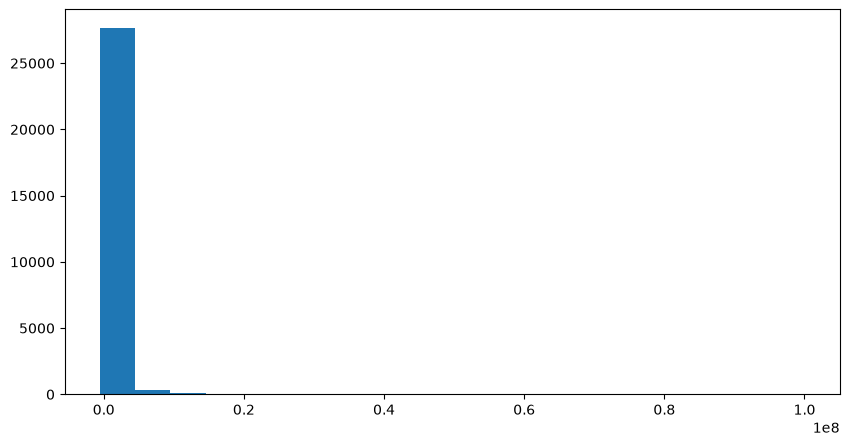

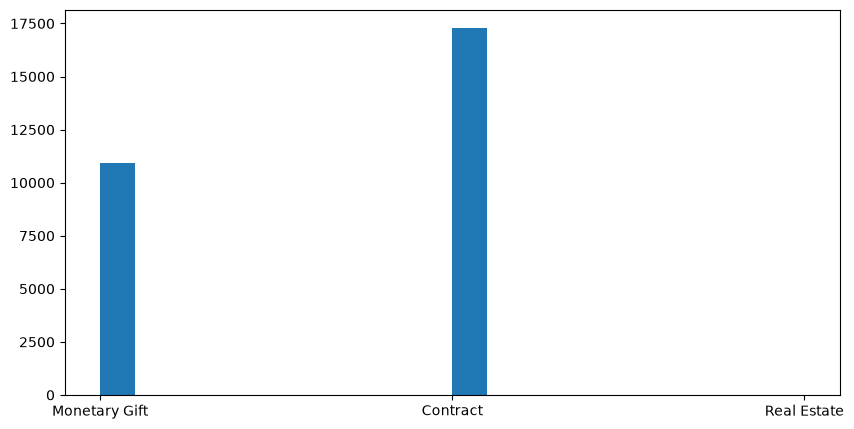

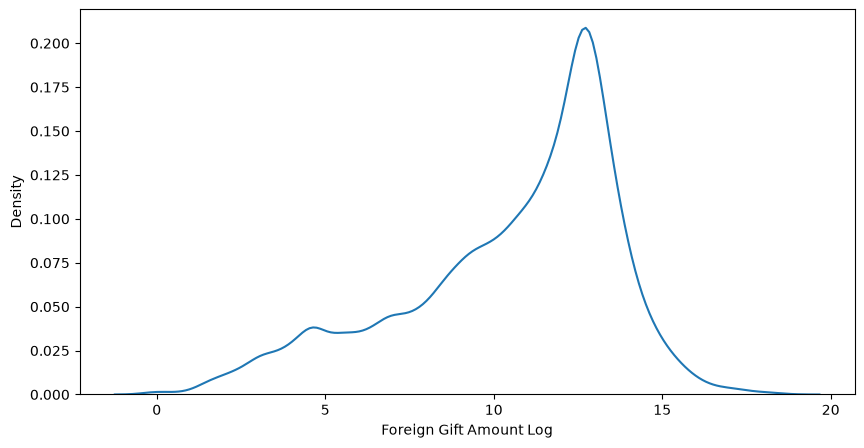

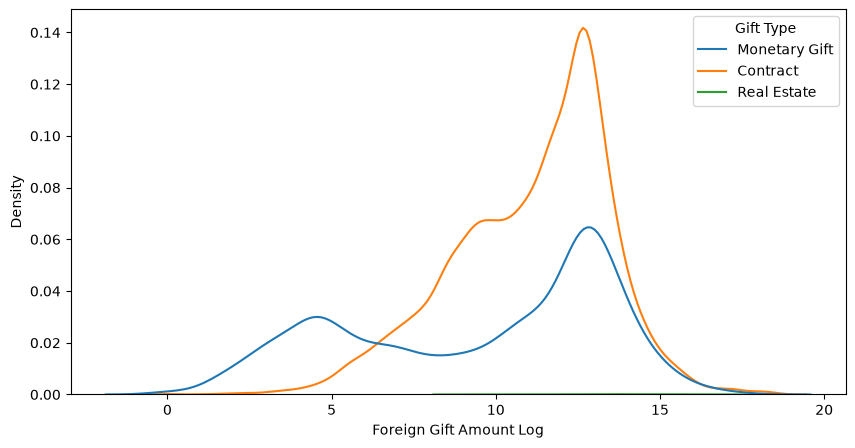

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/cakos/OneDrive - University of Virginia/Foundation_ML_Code/A02-eda-and-visualization/data/ForeignGifts_edu.csv')
plt.figure(figsize=(10,5)) # fix sizing
df['Foreign Gift Amount'].hist(bins=20, grid=False)
print("shape: \n", df.shape)
df['Foreign Gift Amount'].describe()
# the data is mainly all congregated around the 0.0 section and is poorly scaled
plt.figure(figsize=(10,5))
df['Gift Type'].hist(bins=20, grid = False)
print("unique values in gift type column: \n", df['Gift Type'].unique()) # unique values in the column 
print("count of each gift type: \n", df['Gift Type'].value_counts())
df.groupby("Gift Type")["Foreign Gift Amount"].count()
proportion_real_estate = (df["Gift Type"] == "Real Estate").mean()
print(proportion_real_estate * 100) # 0.04%

proportion_contract = (df["Gift Type"] == "Contract").mean()
print(proportion_contract * 100) # 61.21%

proportion_monetary = (df["Gift Type"] == "Monetary Gift").mean()
print(proportion_monetary * 100) # 38.75%

# kernal density plot of the log of Foreign gift amount
plt.figure(figsize = (10, 5))

print("empty rows", (df['Foreign Gift Amount'] <= 0).sum()) # check for zeroes and negatives (handle warning); 24

#create copy of df ( just for this question) with only the positive values for that column
df_noempty_or_neg= df[df['Foreign Gift Amount']>0].copy()
df_noempty_or_neg['Foreign Gift Amount Log'] = np.log(df_noempty_or_neg['Foreign Gift Amount']) # get the log of foreign gift amount
sns.kdeplot(data=df_noempty_or_neg, x = 'Foreign Gift Amount Log') # kde plot
plt.show()
# kernal density plot based on conditional
# source: https://seaborn.pydata.org/examples/multiple_conditional_kde.html
plt.figure(figsize = (10, 5))
sns.kdeplot(data=df_noempty_or_neg, x= 'Foreign Gift Amount Log', hue = 'Gift Type')
plt.show()

# both are skewed to the left. real estate is essentially flat indicating that there's barely any real
# estate gifts in the data set. Tall peak for Contracts, around 12- 13 indicating that they're fairly consistnt. 
# monetary gifts are broader indicating that it varies in size.

# top 15 countries in number of gifts

# ascending = false because sort_values is ordered from smallest -> largest

print(df.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False).head(15)
)# england, china, canada, japan, switzerland, saudi arabia, france, germany, hong kong, south korea
# qatar, the netherlands, korea, india, taiwan

# top 15 counters in terms of amout of gifts given
print(df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
)# qatar, england, china, saudi arabia, bermuda, canada, hong kong, japan, switzerland, india, germany
# united arab emirates, france, singapore, australia 


# which giftors provide the most money , in total?
    # QATAR Foundation  1,166,503,744
print(df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(1))

df.to_csv('updated_ForeignGifts.csv',index = False) # create a new file and leave original file untouched


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:**  [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]